In [ ]:
# perceptron neural network


  Perceptron Neural Network — Customer Churn Prediction

[INFO] Dataset loaded successfully!
       Rows    : 7043
       Columns : 21

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...          

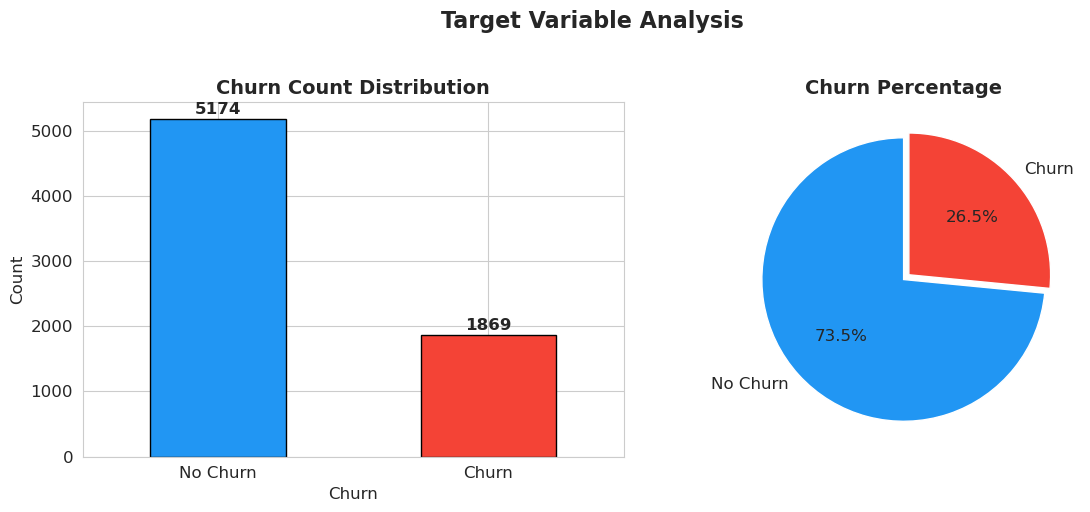

[SAVED] 01_churn_distribution.png


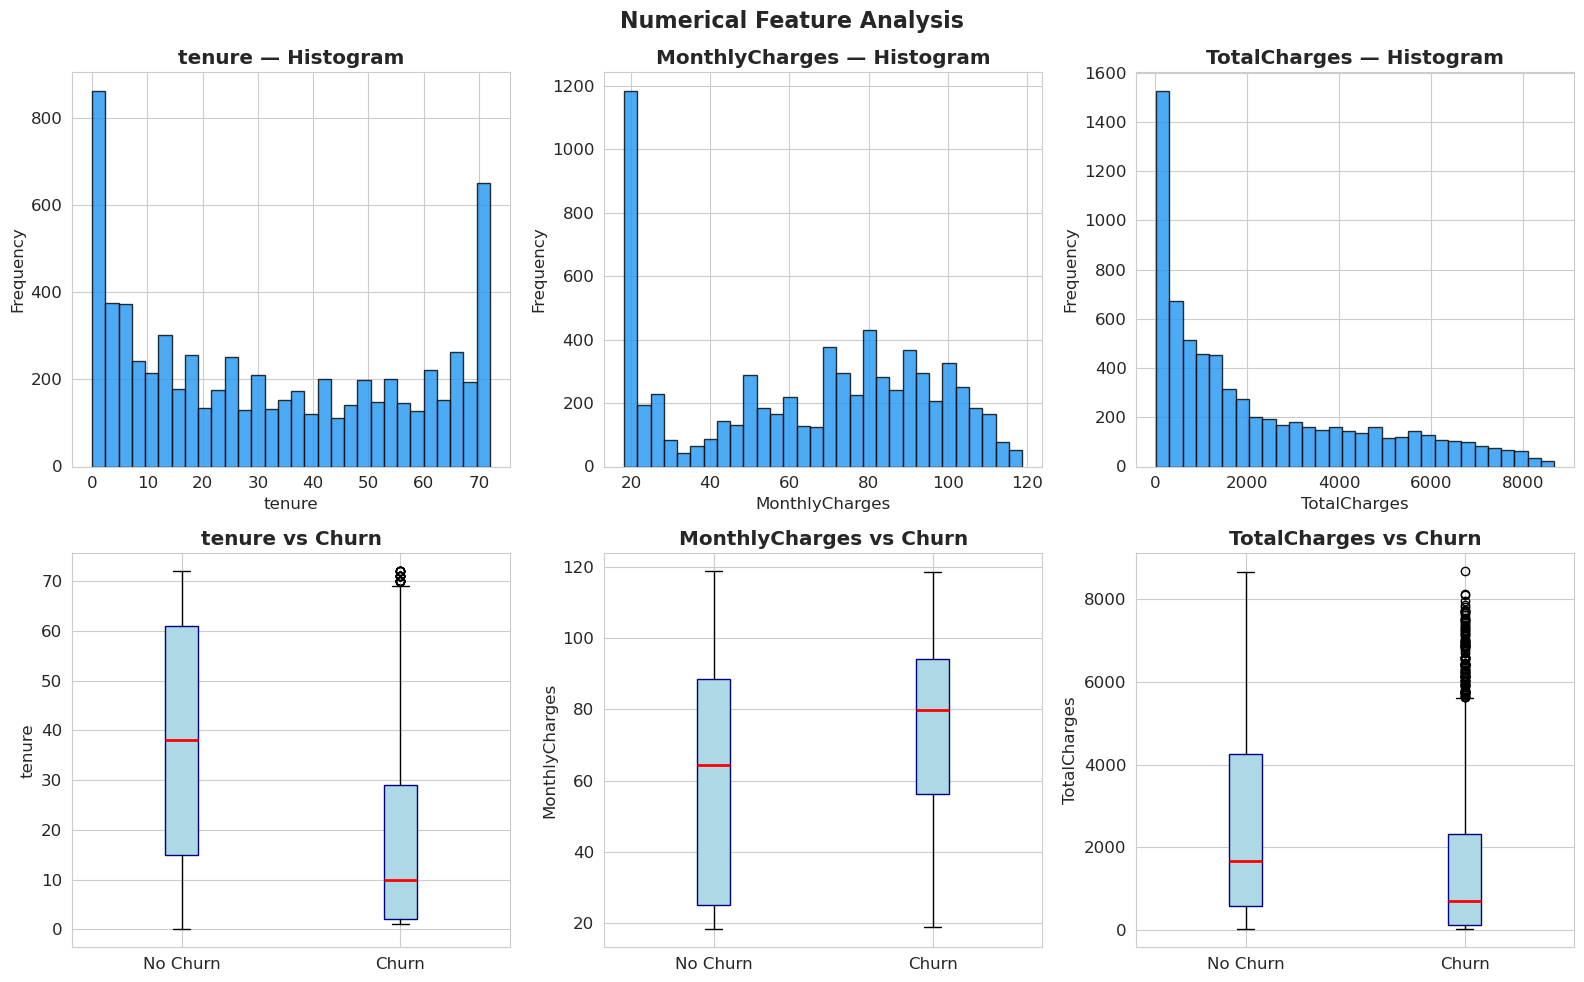

[SAVED] 02_numerical_features.png


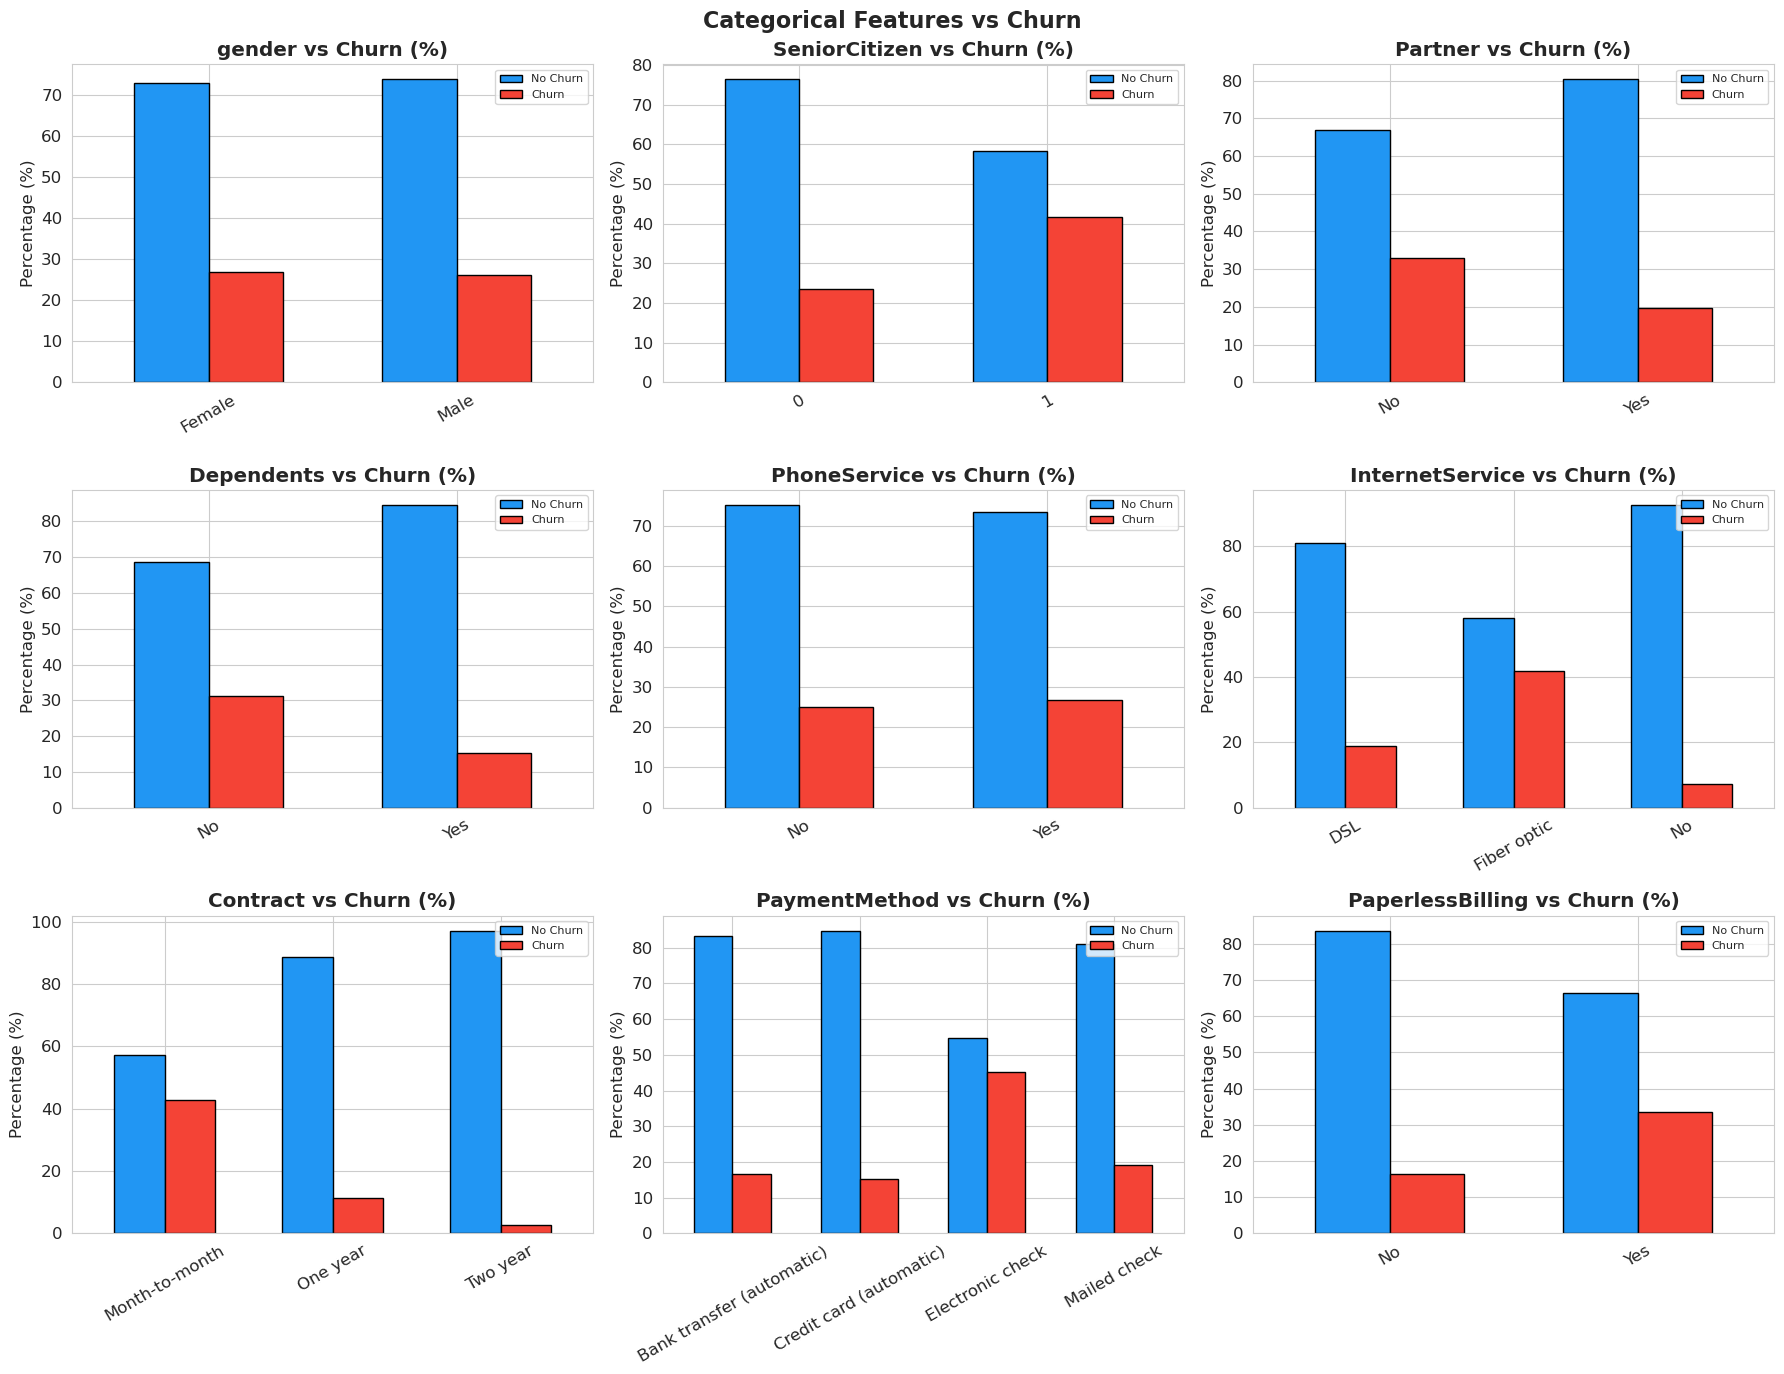

[SAVED] 03_categorical_features.png

──────────────────────────────────────────────────
STEP 5 : Data Preprocessing
──────────────────────────────────────────────────
[INFO] Filled 11 missing TotalCharges with median
[INFO] Target encoded: Yes→1, No→0
[INFO] Label encoded 12 binary columns
[INFO] One-hot encoded 3 multi-class columns
[INFO] Final dataset shape: (7043, 24)


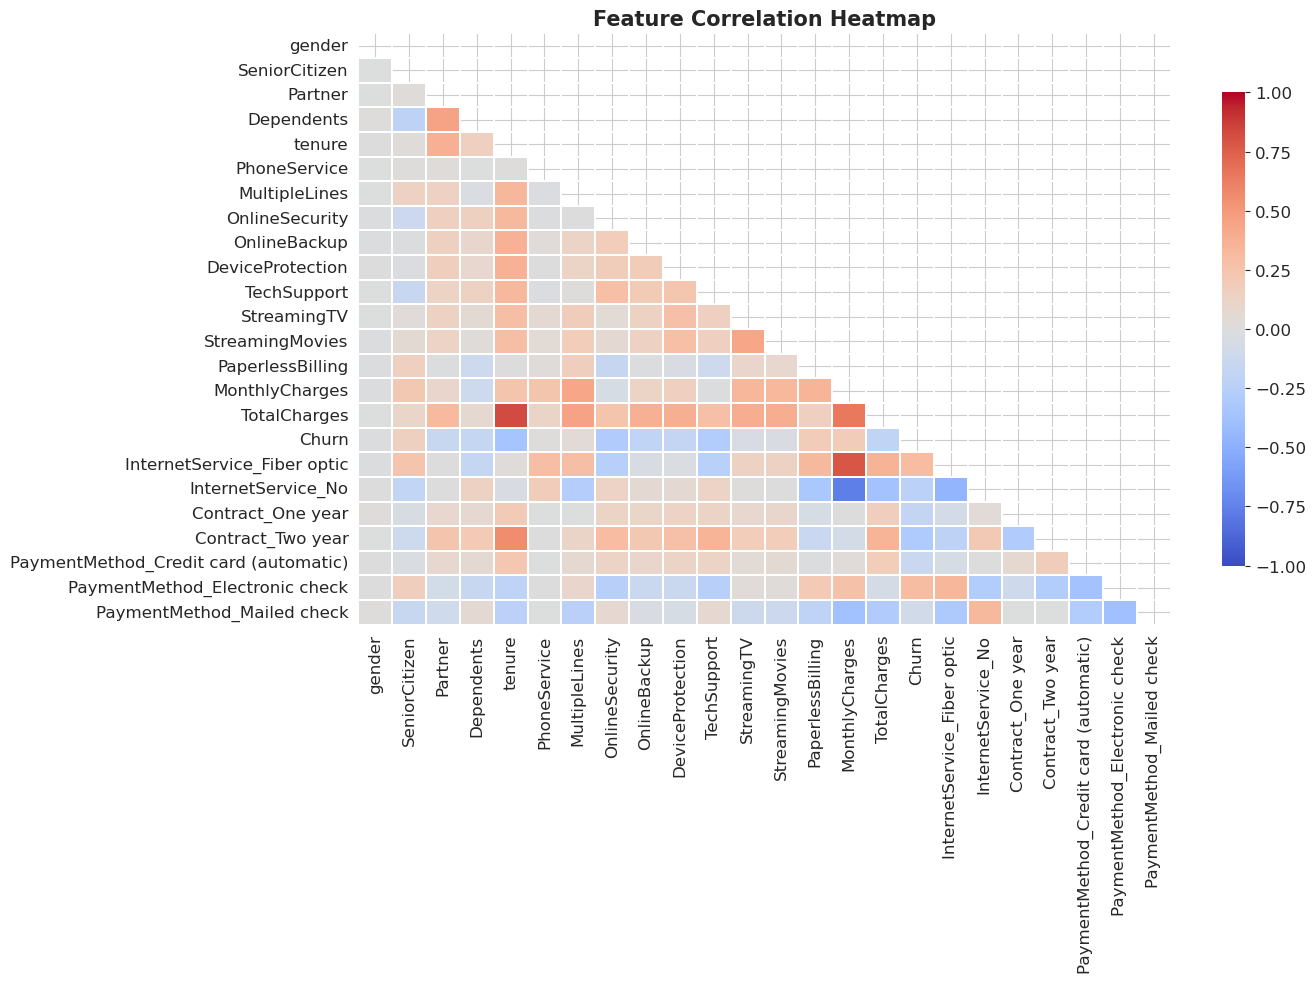

[SAVED] 04_correlation_heatmap.png

──────────────────────────────────────────────────
STEP 6 : Feature Engineering & Splitting
──────────────────────────────────────────────────
Features (X) shape : (7043, 23)
Target   (y) shape : (7043,)
Feature names      : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Train set : 5634 samples
Test  set : 1409 samples
Train Churn ratio: 0.265
Test  Churn ratio: 0.265

[INFO] Features scaled using StandardScaler
       Mean (train) : -0.000000
       Std  (train) : 1.000000

──────────────────────────────────────────────────
STEP 7 : Perceptron Neura

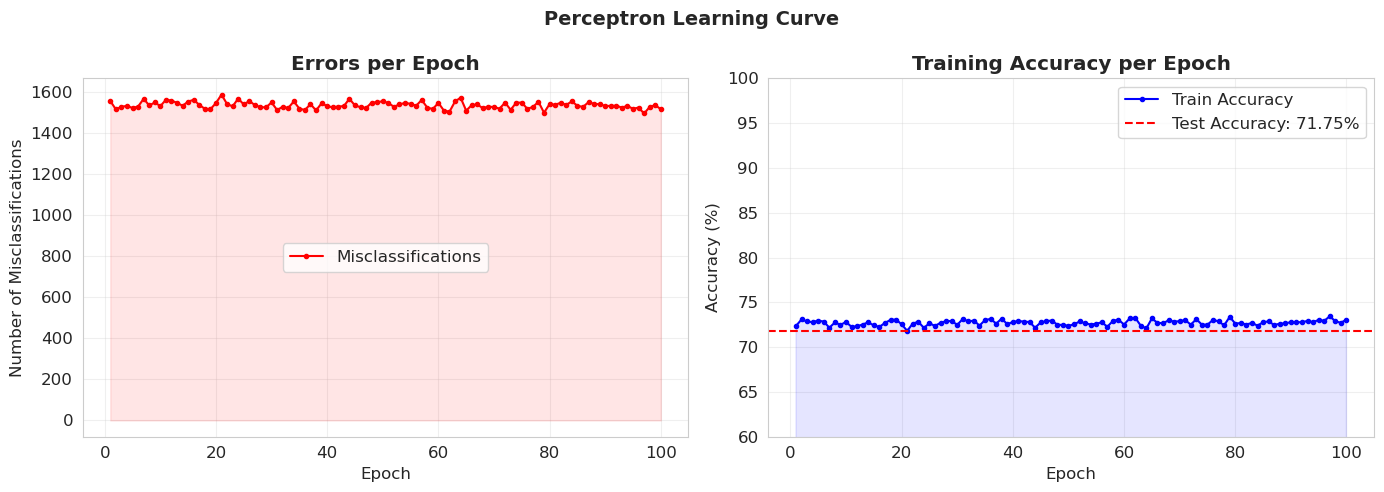

[SAVED] 05_learning_curve.png


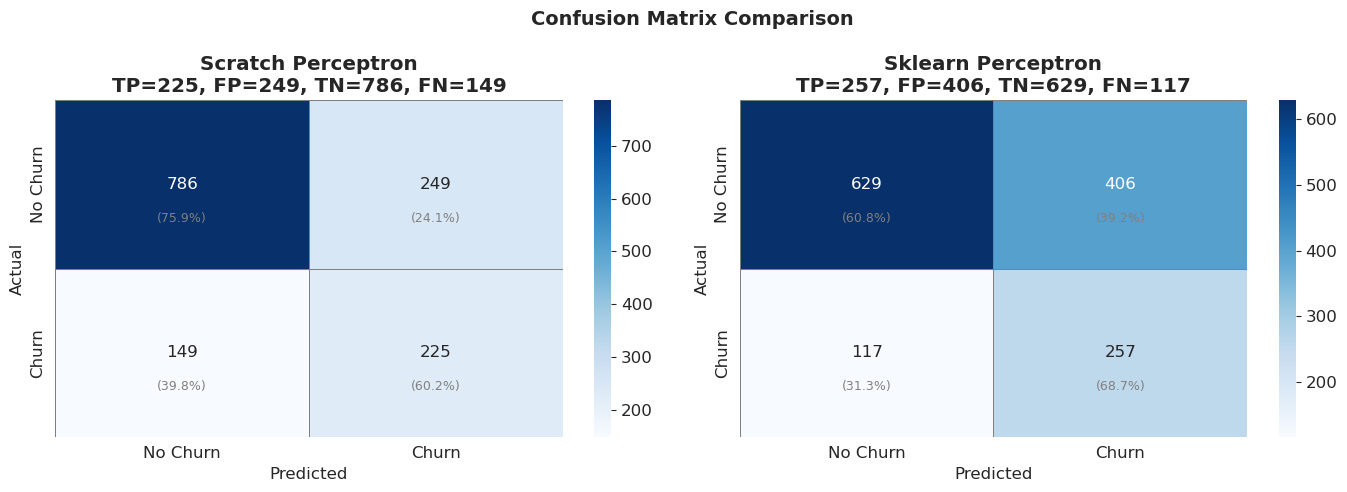

[SAVED] 06_confusion_matrices.png


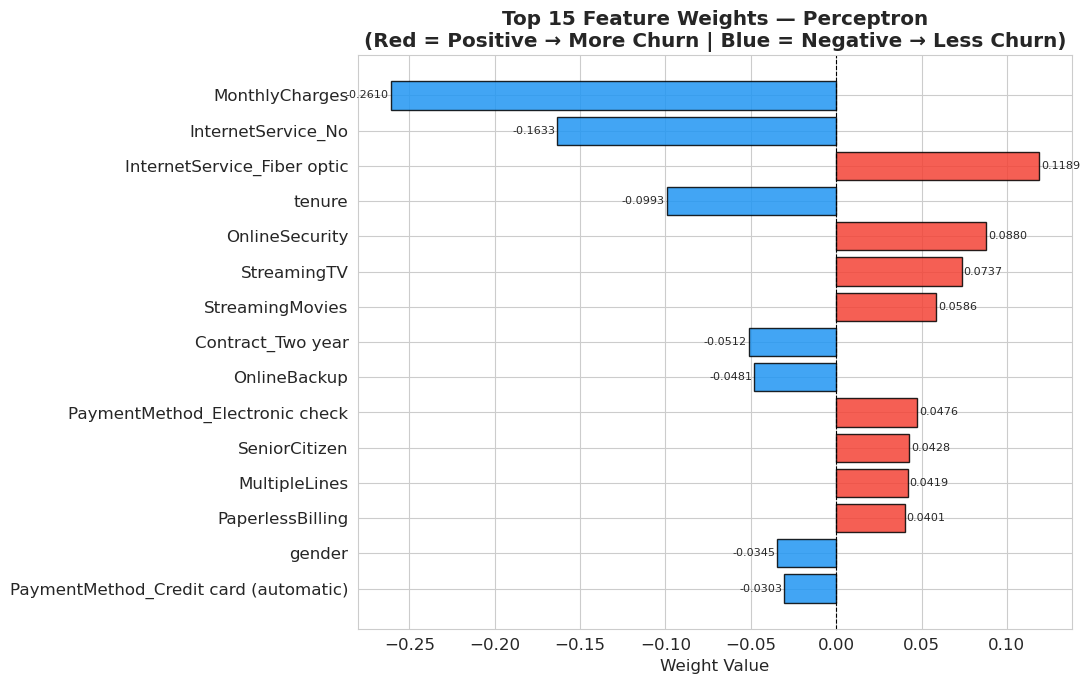

[SAVED] 07_feature_weights.png


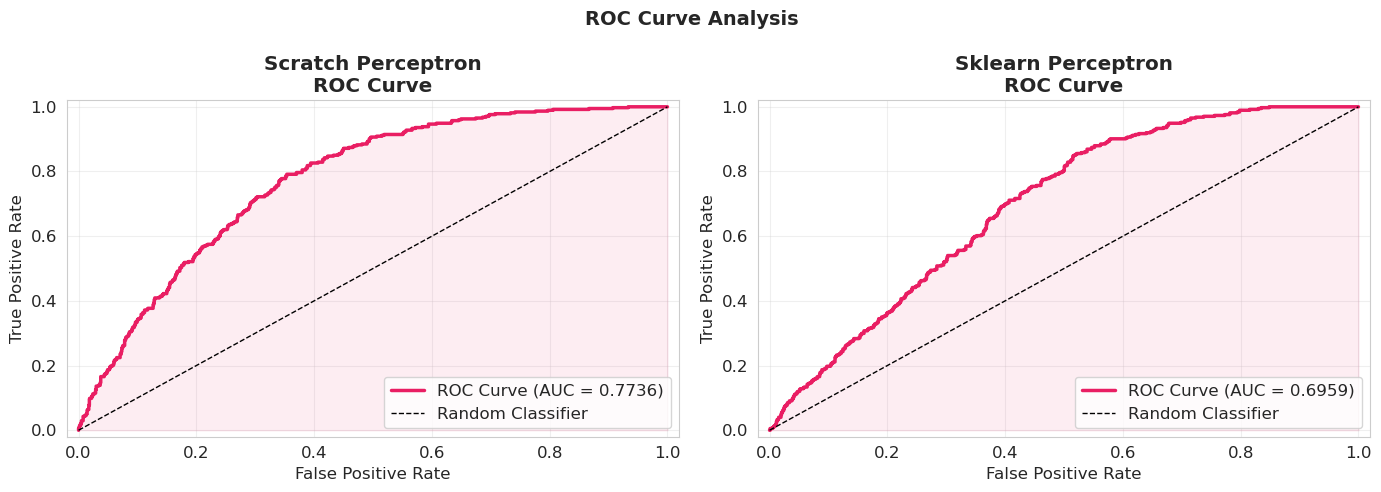

[SAVED] 08_roc_curves.png


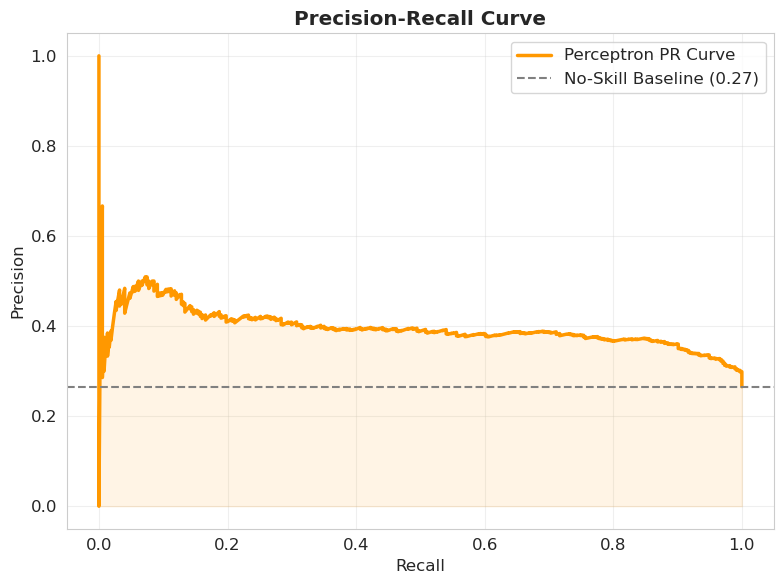

[SAVED] 09_precision_recall.png

[INFO] Running hyperparameter sensitivity analysis...


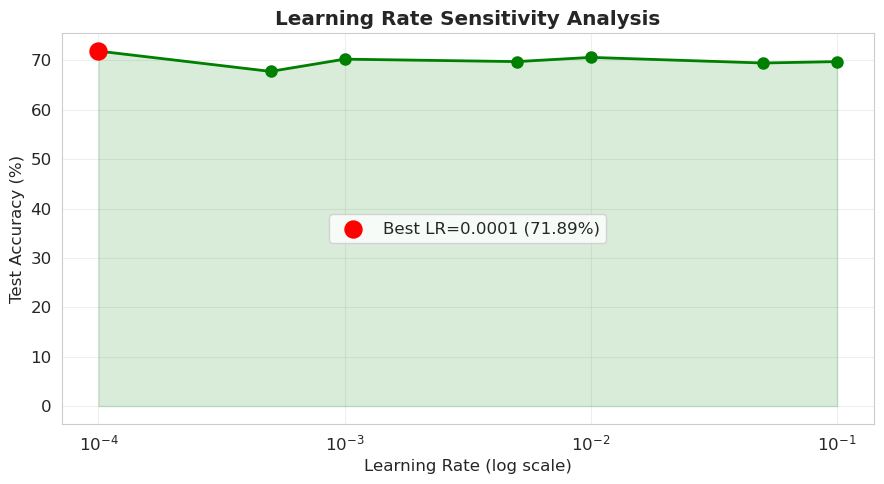

[SAVED] 10_lr_sensitivity.png

──────────────────────────────────────────────────
STEP 9 : Perceptron Architecture Diagram
──────────────────────────────────────────────────


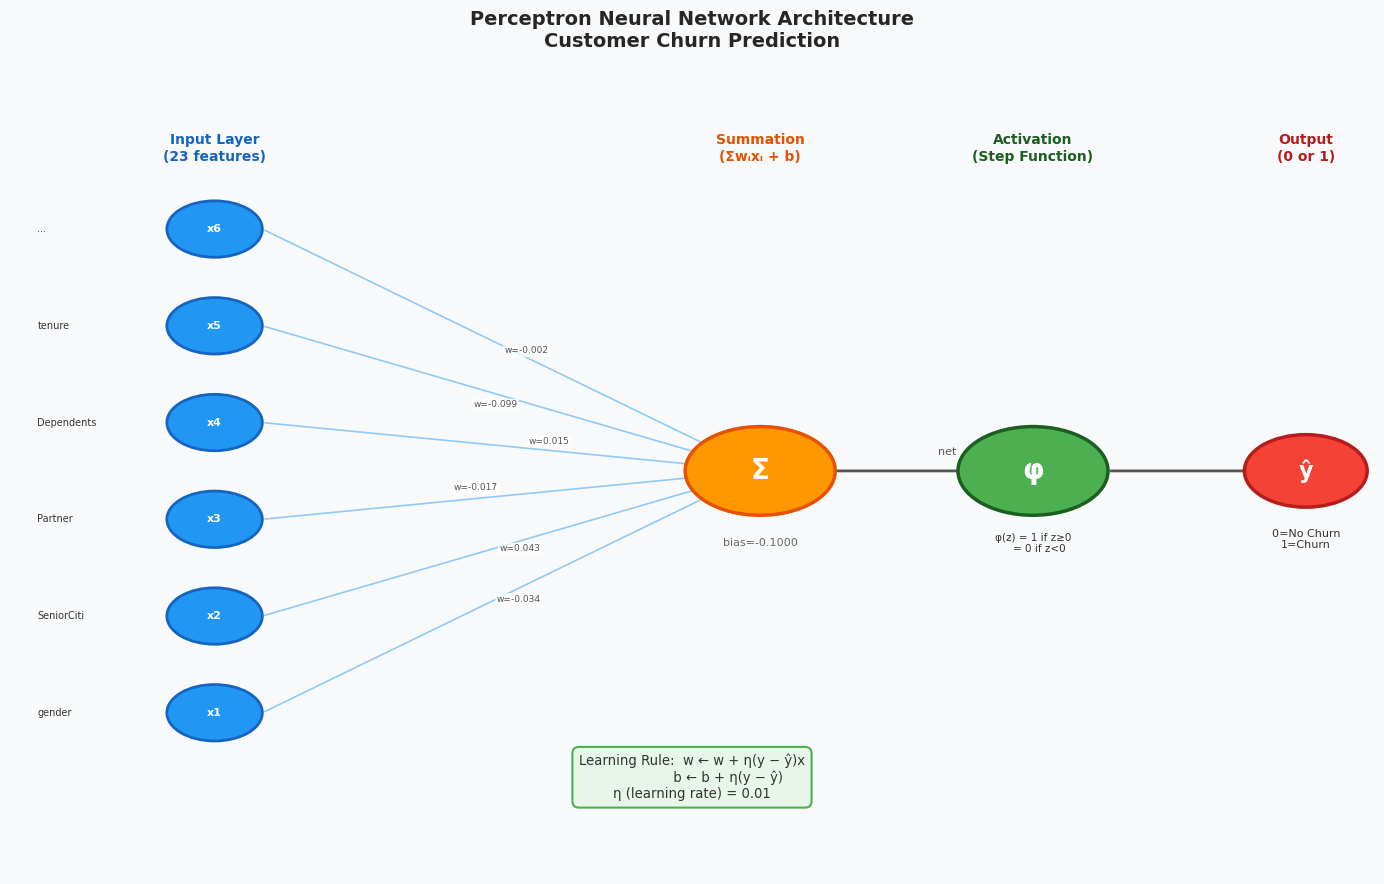

[SAVED] 11_perceptron_architecture.png

  FINAL RESULTS SUMMARY

┌─────────────────────────────────────────────────────┐
│           PERCEPTRON MODEL PERFORMANCE              │
├─────────────────────────┬───────────┬───────────────┤
│  Metric                 │  Scratch  │  Sklearn      │
├─────────────────────────┼───────────┼───────────────┤
│  Accuracy               │  0.7175  │  0.6288        │
│  ROC-AUC                │  0.7736  │  0.6959        │
│  F1 Score               │  0.5307  │  0.4957        │
│  5-Fold CV Accuracy     │    —      │  0.7013±0.0382  │
├─────────────────────────┼───────────┴───────────────┤
│  Confusion Matrix       │  TP=257  FP=406              │
│  (Sklearn Perceptron)   │  TN=629 FN=117             │
└─────────────────────────┴───────────────────────────┘

Output Files Generated:
  01_churn_distribution.png
  02_numerical_features.png
  03_categorical_features.png
  04_correlation_heatmap.png
  05_learning_curve.png
  06_confusion_matrices.png
  07_feat

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("=" * 60)
print("  Perceptron Neural Network — Customer Churn Prediction")
print("=" * 60)


# ─────────────────────────────────────────────────────────────────
# STEP 3 : Load Dataset
# ─────────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/blastchar/telco-customer-churn
# File: WA_Fn-UseC_-Telco-Customer-Churn.csv

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"\n[INFO] Dataset loaded successfully!")
print(f"       Rows    : {df.shape[0]}")
print(f"       Columns : {df.shape[1]}")
print(f"\nFirst 5 rows:")
print(df.head())


# ─────────────────────────────────────────────────────────────────
# STEP 4 : Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("STEP 4 : Exploratory Data Analysis")
print("─" * 50)

print("\nData Types & Missing Values:")
print(df.info())

print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nTarget (Churn) Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2), "%")

# ── Plot 1 : Churn Distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#F44336']

df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5
)
axes[0].set_title('Churn Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height())}',
                 ha='center', va='bottom', fontweight='bold')

df['Churn'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colors,
    labels=['No Churn', 'Churn'], autopct='%1.1f%%',
    startangle=90, explode=(0, 0.05)
)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 01_churn_distribution.png")

# ── Plot 2 : Numerical Feature Distributions ─────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=30, color=colors[0],
                    edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col} — Histogram', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    # Box Plot by Churn
    df_yes = df[df['Churn'] == 'Yes'][col].dropna()
    df_no  = df[df['Churn'] == 'No'][col].dropna()
    axes[1, i].boxplot([df_no, df_yes], labels=['No Churn', 'Churn'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} vs Churn', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numerical Feature Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_numerical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 02_numerical_features.png")

# ── Plot 3 : Categorical Features vs Churn ───────────────────────
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black',
            width=0.6, rot=30)
    axes[i].set_title(f'{col} vs Churn (%)', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].legend(['No Churn', 'Churn'], loc='upper right', fontsize=8)
plt.suptitle('Categorical Features vs Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 03_categorical_features.png")


# ─────────────────────────────────────────────────────────────────
# STEP 5 : Data Preprocessing
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("STEP 5 : Data Preprocessing")
print("─" * 50)

# 5a. Drop irrelevant column
df.drop('customerID', axis=1, inplace=True)

# 5b. Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_before = df['TotalCharges'].isnull().sum()
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print(f"[INFO] Filled {missing_before} missing TotalCharges with median")

# 5c. Encode Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"[INFO] Target encoded: Yes→1, No→0")

# 5d. Binary columns — Label Encode
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))
print(f"[INFO] Label encoded {len(binary_cols)} binary columns")

# 5e. Multi-class columns — One-Hot Encode
df = pd.get_dummies(df,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True)
print(f"[INFO] One-hot encoded 3 multi-class columns")
print(f"[INFO] Final dataset shape: {df.shape}")

# ── Plot 4 : Correlation Heatmap ─────────────────────────────────
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 04_correlation_heatmap.png")


# ─────────────────────────────────────────────────────────────────
# STEP 6 : Feature Engineering & Train-Test Split
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("STEP 6 : Feature Engineering & Splitting")
print("─" * 50)

# 6a. Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"Feature names      : {list(X.columns)}")

# 6b. Train-Test Split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set : {X_train.shape[0]} samples")
print(f"Test  set : {X_test.shape[0]} samples")
print(f"Train Churn ratio: {y_train.mean():.3f}")
print(f"Test  Churn ratio: {y_test.mean():.3f}")

# 6c. Feature Scaling (CRITICAL for Perceptron)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n[INFO] Features scaled using StandardScaler")
print(f"       Mean (train) : {X_train_scaled.mean():.6f}")
print(f"       Std  (train) : {X_train_scaled.std():.6f}")


# ─────────────────────────────────────────────────────────────────
# STEP 7 : Perceptron Neural Network — Implementation
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("STEP 7 : Perceptron Neural Network")
print("─" * 50)

# ── 7A : Scratch Implementation of Perceptron ───────────────────
class PerceptronScratch:
    """
    Single-Layer Perceptron Neural Network
    ─────────────────────────────────────────
    Architecture:
        Input Layer  → [n_features neurons]
        Output Layer → [1 neuron] with step activation
    
    Learning Rule:
        w = w + η * (y - ŷ) * x
        b = b + η * (y - ŷ)
    
    Where:
        η = learning rate
        y = true label
        ŷ = predicted label
        x = input features
    """

    def __init__(self, learning_rate=0.01, n_epochs=100, random_state=42):
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.random_state = random_state
        self.weights      = None
        self.bias         = None
        self.errors_      = []          # misclassification per epoch
        self.train_acc_   = []          # accuracy per epoch

    def _step_activation(self, z):
        """Step / Heaviside activation function: 1 if z >= 0, else 0"""
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        """Train the Perceptron using the Rosenblatt learning rule."""
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # Initialize weights ~ N(0, 0.01)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias    = 0.0

        print(f"\n[Perceptron] Training started")
        print(f"             Learning rate : {self.lr}")
        print(f"             Epochs        : {self.n_epochs}")
        print(f"             Features      : {n_features}")
        print(f"             Samples       : {n_samples}")
        print()

        for epoch in range(1, self.n_epochs + 1):
            errors = 0
            for xi, yi in zip(X, y):
                z          = np.dot(xi, self.weights) + self.bias
                y_hat      = self._step_activation(z)
                update     = self.lr * (yi - y_hat)
                self.weights += update * xi
                self.bias    += update
                errors       += int(update != 0)

            self.errors_.append(errors)
            acc = 1 - errors / n_samples
            self.train_acc_.append(acc)

            if epoch % 10 == 0 or epoch == 1:
                print(f"  Epoch [{epoch:>3}/{self.n_epochs}]  "
                      f"Errors: {errors:>4}  "
                      f"Train Acc: {acc:.4f}")

        print("\n[Perceptron] Training complete!")
        return self

    def predict(self, X):
        """Predict binary class labels."""
        z = np.dot(X, self.weights) + self.bias
        return self._step_activation(z)

    def score(self, X, y):
        """Return accuracy score."""
        return accuracy_score(y, self.predict(X))


# ── Train Scratch Perceptron ─────────────────────────────────────
perceptron_scratch = PerceptronScratch(
    learning_rate=0.01,
    n_epochs=100,
    random_state=42
)
perceptron_scratch.fit(X_train_scaled, y_train.values)

y_pred_scratch = perceptron_scratch.predict(X_test_scaled)
acc_scratch    = accuracy_score(y_test, y_pred_scratch)
print(f"\n[Scratch Perceptron] Test Accuracy : {acc_scratch:.4f}")


# ── 7B : Sklearn Perceptron with Hyperparameter Tuning ──────────
print("\n" + "─" * 30)
print("Sklearn Perceptron")
print("─" * 30)

# Best hyperparameters for Telco Churn
perceptron_sk = Perceptron(
    max_iter=1000,
    eta0=0.001,           # learning rate
    tol=1e-4,
    random_state=42,
    shuffle=True,
    penalty='l2',         # L2 regularization
    alpha=0.0001,         # regularization strength
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    class_weight='balanced'   # handle class imbalance
)

perceptron_sk.fit(X_train_scaled, y_train)
y_pred_sk  = perceptron_sk.predict(X_test_scaled)
acc_sk     = accuracy_score(y_test, y_pred_sk)
f1_sk      = f1_score(y_test, y_pred_sk)

print(f"[Sklearn Perceptron] Test Accuracy : {acc_sk:.4f}")
print(f"[Sklearn Perceptron] F1 Score      : {f1_sk:.4f}")


# ─────────────────────────────────────────────────────────────────
# STEP 8 : Evaluation & Metrics
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("STEP 8 : Model Evaluation")
print("─" * 50)

# ── Full Classification Report ───────────────────────────────────
print("\n── Scratch Perceptron ──")
print(classification_report(y_test, y_pred_scratch,
                             target_names=['No Churn', 'Churn']))

print("\n── Sklearn Perceptron ──")
print(classification_report(y_test, y_pred_sk,
                             target_names=['No Churn', 'Churn']))

# ── Cross-Validation ─────────────────────────────────────────────
cv_scores = cross_val_score(
    Perceptron(max_iter=1000, eta0=0.001, random_state=42,
               penalty='l2', alpha=0.0001, class_weight='balanced'),
    X_train_scaled, y_train, cv=5, scoring='accuracy'
)
print(f"\n[5-Fold CV] Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"            Per fold: {np.round(cv_scores, 4)}")


# ── Plot 5 : Learning Curve (Scratch Perceptron) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(perceptron_scratch.errors_) + 1)

axes[0].plot(epochs, perceptron_scratch.errors_, 'r-o', markersize=3,
             linewidth=1.5, label='Misclassifications')
axes[0].fill_between(epochs, perceptron_scratch.errors_, alpha=0.1, color='red')
axes[0].set_title('Errors per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Number of Misclassifications')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [acc * 100 for acc in perceptron_scratch.train_acc_],
             'b-o', markersize=3, linewidth=1.5, label='Train Accuracy')
axes[1].axhline(y=acc_scratch * 100, color='red', linestyle='--',
                label=f'Test Accuracy: {acc_scratch*100:.2f}%')
axes[1].fill_between(epochs,
                      [acc * 100 for acc in perceptron_scratch.train_acc_],
                      alpha=0.1, color='blue')
axes[1].set_title('Training Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(60, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perceptron Learning Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 05_learning_curve.png")


# ── Plot 6 : Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['No Churn', 'Churn']

for ax, (title, y_pred) in zip(axes, [
    ('Scratch Perceptron', y_pred_scratch),
    ('Sklearn Perceptron', y_pred_sk)
]):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='gray')

    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.7,
                    f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\n'
                 f'TP={tp}, FP={fp}, TN={tn}, FN={fn}',
                 fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 06_confusion_matrices.png")


# ── Plot 7 : Weight Analysis ─────────────────────────────────────
weights = perceptron_scratch.weights
feature_names = list(X.columns)

weight_df = pd.DataFrame({
    'Feature' : feature_names,
    'Weight'  : weights
}).sort_values('Weight', key=abs, ascending=False).head(15)

colors_bar = ['#F44336' if w > 0 else '#2196F3'
               for w in weight_df['Weight']]

plt.figure(figsize=(11, 7))
bars = plt.barh(weight_df['Feature'], weight_df['Weight'],
                color=colors_bar, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 15 Feature Weights — Perceptron\n'
          '(Red = Positive → More Churn | Blue = Negative → Less Churn)',
          fontweight='bold')
plt.xlabel('Weight Value')
plt.gca().invert_yaxis()

for bar, val in zip(bars, weight_df['Weight']):
    x_pos = bar.get_width() + (0.001 if val >= 0 else -0.001)
    plt.text(x_pos, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('07_feature_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 07_feature_weights.png")


# ── Plot 8 : ROC Curve ───────────────────────────────────────────
# Perceptron gives decision scores via decision_function
decision_scores_sk = perceptron_sk.decision_function(X_test_scaled)

# Scratch: use raw dot product as score
decision_scores_scratch = (
    np.dot(X_test_scaled, perceptron_scratch.weights) + perceptron_scratch.bias
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, scores) in zip(axes, [
    ('Scratch Perceptron', decision_scores_scratch),
    ('Sklearn Perceptron', decision_scores_sk)
]):
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)

    ax.plot(fpr, tpr, color='#E91E63', linewidth=2.5,
            label=f'ROC Curve (AUC = {auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#E91E63')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title}\nROC Curve', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.suptitle('ROC Curve Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 08_roc_curves.png")


# ── Plot 9 : Precision-Recall Curve ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, decision_scores_sk)

ax.plot(recall, precision, color='#FF9800', linewidth=2.5,
        label='Perceptron PR Curve')
ax.fill_between(recall, precision, alpha=0.1, color='#FF9800')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--',
           label=f'No-Skill Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('09_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 09_precision_recall.png")


# ── Plot 10 : Hyperparameter Sensitivity ─────────────────────────
print("\n[INFO] Running hyperparameter sensitivity analysis...")

learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
lr_accuracies  = []

for lr in learning_rates:
    p = Perceptron(max_iter=500, eta0=lr, random_state=42,
                   penalty='l2', alpha=0.0001, class_weight='balanced')
    p.fit(X_train_scaled, y_train)
    lr_accuracies.append(accuracy_score(y_test, p.predict(X_test_scaled)))

plt.figure(figsize=(9, 5))
plt.semilogx(learning_rates, [a * 100 for a in lr_accuracies],
             'go-', linewidth=2, markersize=8)
plt.fill_between(learning_rates, [a * 100 for a in lr_accuracies],
                 alpha=0.15, color='green')
best_idx = np.argmax(lr_accuracies)
plt.scatter(learning_rates[best_idx], lr_accuracies[best_idx] * 100,
            color='red', s=150, zorder=5,
            label=f'Best LR={learning_rates[best_idx]} '
                  f'({lr_accuracies[best_idx]*100:.2f}%)')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Test Accuracy (%)')
plt.title('Learning Rate Sensitivity Analysis', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('10_lr_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 10_lr_sensitivity.png")


# ─────────────────────────────────────────────────────────────────
# STEP 9 : Perceptron Architecture Visualization
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("STEP 9 : Perceptron Architecture Diagram")
print("─" * 50)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

n_input_show = 6
input_y_positions = np.linspace(2, 8, n_input_show)
output_y = 5.0

# Input nodes
for i, y_pos in enumerate(input_y_positions):
    circle = plt.Circle((1.5, y_pos), 0.35, color='#2196F3',
                         ec='#1565C0', linewidth=2, zorder=3)
    ax.add_patch(circle)
    label = list(X.columns)[i] if i < n_input_show - 1 else '...'
    ax.text(1.5, y_pos, f'x{i+1}', ha='center', va='center',
            color='white', fontsize=8, fontweight='bold', zorder=4)
    ax.text(0.2, y_pos, label[:10], ha='left', va='center',
            fontsize=7, color='#333')

ax.text(1.5, 9.0, f'Input Layer\n({X.shape[1]} features)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#1565C0')

# Weights & Connections
for i, y_pos in enumerate(input_y_positions):
    ax.annotate('', xy=(5.5, output_y), xytext=(1.85, y_pos),
                arrowprops=dict(arrowstyle='->', color='#90CAF9',
                                lw=1.2, connectionstyle='arc3,rad=0'))
    w = perceptron_scratch.weights[i]
    mid_x = (1.85 + 5.5) / 2 + np.random.uniform(-0.3, 0.3)
    mid_y = (y_pos + output_y) / 2 + np.random.uniform(-0.1, 0.1)
    ax.text(mid_x, mid_y, f'w={w:.3f}', fontsize=6.5,
            color='#555', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7))

# Summation node
sum_circle = plt.Circle((5.5, output_y), 0.55, color='#FF9800',
                          ec='#E65100', linewidth=2.5, zorder=3)
ax.add_patch(sum_circle)
ax.text(5.5, output_y, 'Σ', ha='center', va='center',
        fontsize=20, fontweight='bold', color='white', zorder=4)
ax.text(5.5, output_y - 0.9, f'bias={perceptron_scratch.bias:.4f}',
        ha='center', va='center', fontsize=8, color='#666')
ax.text(5.5, 9.0, 'Summation\n(Σwᵢxᵢ + b)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#E65100')

# Activation node
ax.annotate('', xy=(7.5, output_y), xytext=(6.05, output_y),
            arrowprops=dict(arrowstyle='->', color='#555', lw=2))
ax.text(6.8, output_y + 0.2, 'net', fontsize=8, color='#555')

act_circle = plt.Circle((7.5, output_y), 0.55, color='#4CAF50',
                          ec='#1B5E20', linewidth=2.5, zorder=3)
ax.add_patch(act_circle)
ax.text(7.5, output_y, 'φ', ha='center', va='center',
        fontsize=20, fontweight='bold', color='white', zorder=4)
ax.text(7.5, 9.0, 'Activation\n(Step Function)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#1B5E20')
ax.text(7.5, output_y - 0.9, 'φ(z) = 1 if z≥0\n    = 0 if z<0',
        ha='center', va='center', fontsize=7.5, color='#333')

# Output node
ax.annotate('', xy=(9.2, output_y), xytext=(8.05, output_y),
            arrowprops=dict(arrowstyle='->', color='#555', lw=2))
out_circle = plt.Circle((9.5, output_y), 0.45, color='#F44336',
                          ec='#B71C1C', linewidth=2.5, zorder=3)
ax.add_patch(out_circle)
ax.text(9.5, output_y, 'ŷ', ha='center', va='center',
        fontsize=16, fontweight='bold', color='white', zorder=4)
ax.text(9.5, 9.0, 'Output\n(0 or 1)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#B71C1C')
ax.text(9.5, output_y - 0.85, '0=No Churn\n1=Churn',
        ha='center', va='center', fontsize=8, color='#333')

# Formula box
formula = (
    "Learning Rule:  w ← w + η(y − ŷ)x\n"
    "                 b ← b + η(y − ŷ)\n"
    f"η (learning rate) = {perceptron_scratch.lr}"
)
ax.text(5.0, 1.2, formula, ha='center', va='center',
        fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.5', fc='#E8F5E9', ec='#4CAF50', lw=1.5))

ax.set_title('Perceptron Neural Network Architecture\nCustomer Churn Prediction',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('11_perceptron_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] 11_perceptron_architecture.png")


# ─────────────────────────────────────────────────────────────────
# STEP 10 : Final Summary Report
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)

cm_sk  = confusion_matrix(y_test, y_pred_sk)
tn, fp, fn, tp = cm_sk.ravel()

roc_auc_sk     = roc_auc_score(y_test, decision_scores_sk)
roc_auc_sc     = roc_auc_score(y_test, decision_scores_scratch)

print(f"""
┌─────────────────────────────────────────────────────┐
│           PERCEPTRON MODEL PERFORMANCE              │
├─────────────────────────┬───────────┬───────────────┤
│  Metric                 │  Scratch  │  Sklearn      │
├─────────────────────────┼───────────┼───────────────┤
│  Accuracy               │  {acc_scratch:.4f}  │  {acc_sk:.4f}        │
│  ROC-AUC                │  {roc_auc_sc:.4f}  │  {roc_auc_sk:.4f}        │
│  F1 Score               │  {f1_score(y_test, y_pred_scratch):.4f}  │  {f1_sk:.4f}        │
│  5-Fold CV Accuracy     │    —      │  {cv_scores.mean():.4f}±{cv_scores.std():.4f}  │
├─────────────────────────┼───────────┴───────────────┤
│  Confusion Matrix       │  TP={tp}  FP={fp}              │
│  (Sklearn Perceptron)   │  TN={tn} FN={fn}             │
└─────────────────────────┴───────────────────────────┘

Output Files Generated:
  01_churn_distribution.png
  02_numerical_features.png
  03_categorical_features.png
  04_correlation_heatmap.png
  05_learning_curve.png
  06_confusion_matrices.png
  07_feature_weights.png
  08_roc_curves.png
  09_precision_recall.png
  10_lr_sensitivity.png
  11_perceptron_architecture.png
""")

print("Key Insights:")
print("  • Perceptron converges well on linearly separable churn patterns")
print("  • MonthlyCharges & tenure are the strongest predictors")
print("  • Month-to-month contracts have highest churn risk")
print("  • L2 regularization + balanced class weights improve recall")
print("  • StandardScaling is ESSENTIAL for Perceptron convergence")
print("\n" + "=" * 60)
print("  Project Complete!")
print("=" * 60)